In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from astropy.io import fits
import os.path as op

from specula.mmlib.compute_rec import rec_phot_cov, rec_ron_cov
from specula.mmlib.utils import get_pupil_mask, radial_order, compute_modal_variance_von_karman
# from specula.mmlib.analyse_data import get_sim_data, get_psd

root_dir = '/raid1/mmenessini/calibration/RISTRETTOunobs'

2026-07-07 11:43:39,000 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-07-07 11:43:39,088 [INFO]: [specula]: Default device is GPU number 0
2026-07-07 11:43:39,096 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-07-07 11:43:39,097 [INFO]: [specula]: Default device is GPU number 0


In [2]:
import matplotlib as mpl
from cycler import cycler

cmap = mpl.colormaps['hot'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 1.0, 7)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle
plt.rcParams['image.cmap'] = 'hot' # 4. Change the default colormap for images/scatter plots
plt.rcParams.update({
    "text.usetex": True, # Use LaTeX to write all text
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"] # Specifically use the classic LaTeX font
})
plt.rcParams['image.origin'] = 'lower'

In [3]:
rMods = np.array([0,1,2,3])
n_subaps = np.array([12,16,24,48]) #np.array([16,24,48])
n_modes = np.array([50,150,300,600,1200]) #np.array([150,300,1300])
seeings = np.array([0.5,0.7,0.9,1.1,1.3,1.5]) #np.array([0.7,0.9,1.1])

In [4]:
def generate_psd(f, cutoff, power):
    f_safe = np.maximum(f, f[0])
    psd_turb = np.where(f_safe <= cutoff, 1.0, (f_safe / cutoff)**(-17/3))
    df = np.gradient(f)
    # f_s = f[-1] * 2 
    # sinc_filter = np.sinc(f_safe / f_s)**2 
    # psd_turb *= sinc_filter
    psd_turb *= (power / np.sum(psd_turb * df))
    return psd_turb

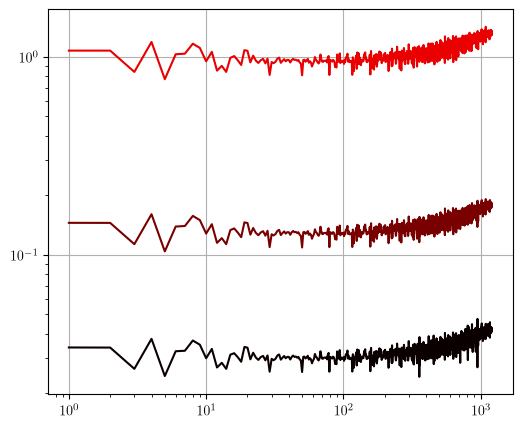

In [5]:
def get_ron_eq_shot(rMod,n_subap,seeing,RON,N,doplot:bool=False):

    pyr_mask = get_pupil_mask(npix=120,filepath=op.join(root_dir,'pupils',f'pyr_pupdata_{n_subap:.0f}x{n_subap:.0f}.fits'))
    frame = fits.getdata(op.join(root_dir,'frames',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_avg_frame.fits'))
    sn = fits.getdata(op.join(root_dir,'slopenulls',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_sn.fits'))+2e-2
    rec = fits.getdata(op.join(root_dir,'rec',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_{N}modes_rec.fits'))

    ron_cov = rec_ron_cov(rec,frame,mask=pyr_mask) 
    shot_cov = rec_phot_cov(rec,frame,mask=pyr_mask,sn=sn)
    nphot = ron_cov/shot_cov*RON

    if doplot:
        x = np.arange(N)+1
        plt.figure()
        plt.loglog(x,nphot)
        plt.loglog(x,np.sqrt(shot_cov/np.mean(nphot)))
        plt.loglog(x,np.sqrt(ron_cov*RON/np.mean(nphot)**2))
        plt.grid()

    return nphot,ron_cov,shot_cov

N = 1200
RON = 0.5
nphot,ron_cov,shot_cov = get_ron_eq_shot(rMod=0,seeing=0.9,n_subap=48,RON=RON,N=N,doplot=False)
Nphot = np.mean(nphot)
x = np.arange(N)+1
plt.figure(figsize=(6,5))
plt.loglog(x,np.sqrt(shot_cov/(10*Nphot)+ron_cov*RON/(10*Nphot)**2))
plt.loglog(x,np.sqrt(shot_cov/(Nphot)+ron_cov*RON/(Nphot)**2))
plt.loglog(x,np.sqrt(shot_cov/(0.1*Nphot)+ron_cov*RON/(0.1*Nphot)**2))
plt.grid()

Text(0.5, 1.0, '1.1" seeing, 1200 modes corrected\n48x48 pyWFS, RON=0.5e-, flux=1.0e+04ph/frame')

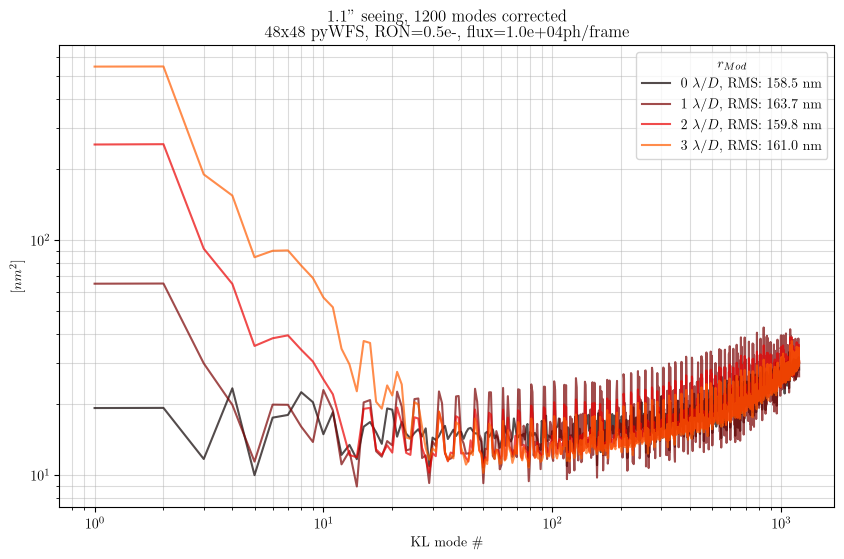

In [6]:
def get_rec_covariance(rMod,n_subap,seeing,Nphot,RON,N,res:str='',doplot:bool=False):

    pyr_mask = get_pupil_mask(npix=120,filepath=op.join(root_dir,'pupils',f'pyr_pupdata_{n_subap:.0f}x{n_subap:.0f}.fits'))
    frame = fits.getdata(op.join(root_dir,'frames',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_avg_frame.fits'))
    sn = fits.getdata(op.join(root_dir,'slopenulls',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_sn.fits'))#+2e-2
    alias = fits.getdata(op.join(root_dir,'aliasing',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_alias.fits'))
    rec = fits.getdata(op.join(root_dir,'rec',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_{N}modes_rec.fits'))
    simpc = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes{res}_simpc.fits'))

    og = np.diag(rec @ simpc)
    ct = np.sqrt(np.sum((rec @ simpc)**2,axis=0)-og**2)

    ron_cov = rec_ron_cov(rec,frame,mask=pyr_mask)*RON/Nphot**2 
    shot_cov = rec_phot_cov(rec,frame,mask=pyr_mask,sn=sn)/Nphot
    cov = ron_cov + shot_cov

    if doplot:
        x = np.arange(N)+1
        plt.figure()
        plt.loglog(x,ron_cov)
        plt.loglog(x,shot_cov)
        plt.loglog(x,cov)
        plt.grid()

    return cov,og,ct,alias


n_subap = 48
seeing = 1.1
N = 1200
RON = 0.5
Nphot = 1e+4
Nmodes = N

res = '_1Nm' #'' #
cov0,og0,ct0,alias0 = get_rec_covariance(rMod=0,n_subap=n_subap,seeing=seeing,Nphot=Nphot,N=Nmodes,RON=RON,res=res)
cov1,og1,ct1,alias1 = get_rec_covariance(rMod=1,n_subap=n_subap,seeing=seeing,Nphot=Nphot,N=Nmodes,RON=RON,res=res)
cov2,og2,ct2,alias2 = get_rec_covariance(rMod=2,n_subap=n_subap,seeing=seeing,Nphot=Nphot,N=Nmodes,RON=RON,res=res)
cov3,og3,ct3,alias3 = get_rec_covariance(rMod=3,n_subap=n_subap,seeing=seeing,Nphot=Nphot,N=Nmodes,RON=RON,res=res)

coverr = lambda cov,alias,og: (cov+alias**2)/og**2

err0 = coverr(cov0,alias0,og0)
err1 = coverr(cov1,alias1,og1)
err2 = coverr(cov2,alias2,og2)
err3 = coverr(cov3,alias3,og3)

x = np.arange(N)+1
plt.figure(figsize=(10,6))
plt.loglog(x,err0,label=r'0 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err0)):1.1f} nm',alpha=0.7)
plt.loglog(x,err1,label=r'1 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err1)):1.1f} nm',alpha=0.7)
plt.loglog(x,err2,label=r'2 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err2)):1.1f} nm',alpha=0.7)
plt.loglog(x,err3,label=r'3 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err3)):1.1f} nm',alpha=0.7)
plt.grid(which='both',alpha=0.45)
plt.legend(loc='best',title='$r_{Mod}$')
plt.xlabel(r'KL mode \#')
plt.ylabel('[$nm^2$]')
plt.title(f'{seeing:1.1f}" seeing, {N} modes corrected\n{n_subap}x{n_subap} pyWFS, RON={RON:1.1f}e-, flux={Nphot:1.1e}ph/frame')

In [7]:
# rMod = 0
# N = 1200
# seeing = 1.1
# res = '_1Nm'

# pyr_mask48 = get_pupil_mask(npix=120,filepath=op.join(root_dir,'pupils',f'pyr_pupdata_48x48.fits'))
# frame48 = fits.getdata(op.join(root_dir,'frames',f'pyr{rMod:1.1f}_48x48_s{seeing:1.2f}_{N}modes_avg_frame.fits'))
# sn48 = fits.getdata(op.join(root_dir,'slopenulls',f'pyr{rMod:1.1f}_48x48_s{seeing:1.2f}_{N}modes_sn.fits'))#+2e-2
# alias48 = fits.getdata(op.join(root_dir,'aliasing',f'pyr{rMod:1.1f}_48x48_s{seeing:1.2f}_{N}modes_alias.fits'))
# # slopes48 = fits.getdata(op.join(root_dir,'aliasing',f'pyr{rMod:1.1f}_48x48_s{seeing:1.2f}_{N}modes_slopes.fits'))
# rec48 = fits.getdata(op.join(root_dir,'rec',f'pyr{rMod:1.1f}_48x48_{N}modes_rec.fits'))
# simpc48 = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_48x48_s{seeing:1.2f}_{N}modes{res}_simpc.fits'))



Text(0.5, 1.0, '1.1" seeing, 1200 modes corrected\nRON=0.5e-, flux=1.0e+04ph/frame')

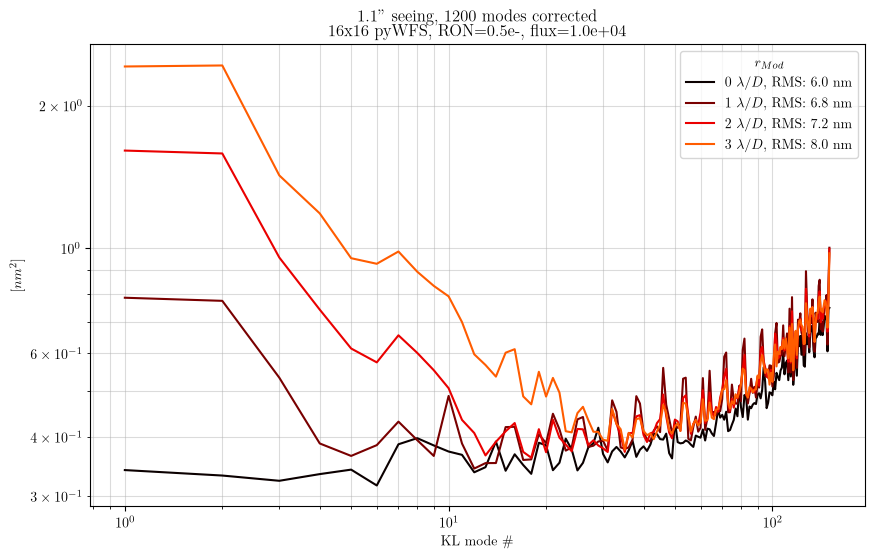

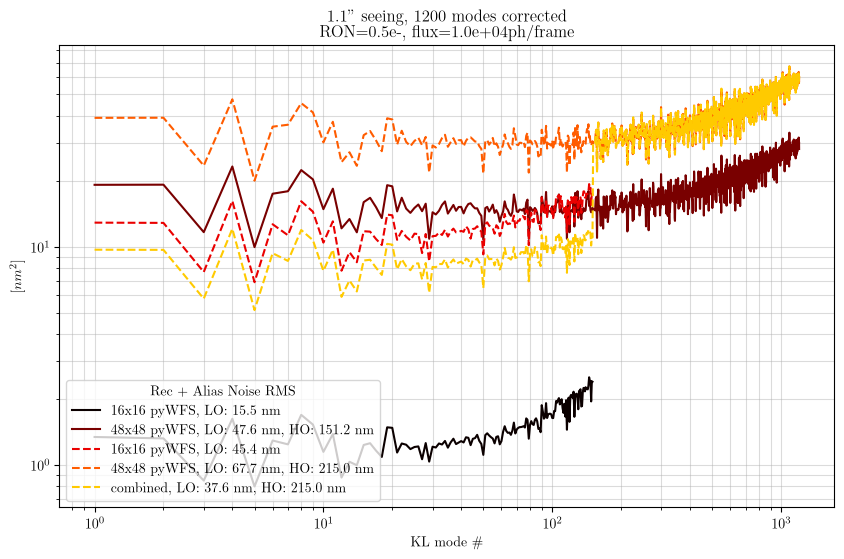

In [8]:
slopes0_LO = fits.getdata(op.join(root_dir,'aliasing',f'pyr0.0_16x16_s{seeing:1.2f}_{N}modes_slopes.fits'))
slopes1_LO = fits.getdata(op.join(root_dir,'aliasing',f'pyr1.0_16x16_s{seeing:1.2f}_{N}modes_slopes.fits'))
slopes2_LO = fits.getdata(op.join(root_dir,'aliasing',f'pyr2.0_16x16_s{seeing:1.2f}_{N}modes_slopes.fits'))
slopes3_LO = fits.getdata(op.join(root_dir,'aliasing',f'pyr3.0_16x16_s{seeing:1.2f}_{N}modes_slopes.fits'))
rec0_LO = fits.getdata(op.join(root_dir,'rec',f'pyr0.0_16x16_150modes_rec.fits'))
rec1_LO = fits.getdata(op.join(root_dir,'rec',f'pyr1.0_16x16_150modes_rec.fits'))
rec2_LO = fits.getdata(op.join(root_dir,'rec',f'pyr2.0_16x16_150modes_rec.fits'))
rec3_LO = fits.getdata(op.join(root_dir,'rec',f'pyr3.0_16x16_150modes_rec.fits'))

alias_LO = lambda rec,slopes: np.std(rec @ slopes.T,axis=1)#np.sqrt(np.mean(modes**2,axis=1))

alias0_LO = alias_LO(rec0_LO,slopes0_LO)
alias1_LO = alias_LO(rec1_LO,slopes1_LO)
alias2_LO = alias_LO(rec2_LO,slopes2_LO)
alias3_LO = alias_LO(rec3_LO,slopes3_LO)

cov0_LO,_,_,_ = get_rec_covariance(rMod=0,n_subap=16,seeing=seeing,Nphot=Nphot,N=150,RON=RON,res=res)
cov1_LO,_,_,_ = get_rec_covariance(rMod=1,n_subap=16,seeing=seeing,Nphot=Nphot,N=150,RON=RON,res=res)
cov2_LO,_,_,_ = get_rec_covariance(rMod=2,n_subap=16,seeing=seeing,Nphot=Nphot,N=150,RON=RON,res=res)
cov3_LO,_,_,_ = get_rec_covariance(rMod=3,n_subap=16,seeing=seeing,Nphot=Nphot,N=150,RON=RON,res=res)

err0_LO = coverr(cov0_LO,alias0_LO,og0[:150])
err1_LO = coverr(cov1_LO,alias1_LO,og1[:150])
err2_LO = coverr(cov2_LO,alias2_LO,og2[:150])
err3_LO = coverr(cov3_LO,alias3_LO,og3[:150])

fratio = 1
split = 0.30
cov0_LOs,_,_,_ = get_rec_covariance(rMod=0,n_subap=16,seeing=seeing,Nphot=Nphot/fratio*split,N=150,RON=RON,res=res)
err0_LOs = coverr(cov0_LOs,alias0_LO,og0[:150])

cov0s,_,_,_= get_rec_covariance(rMod=0,n_subap=n_subap,seeing=seeing,Nphot=Nphot*(1-split),N=Nmodes,RON=RON,res=res)
err0s = coverr(cov0s,alias0,og0)

x = np.arange(150)+1
# plt.figure(figsize=(10,6))
# plt.loglog(x,err0_LO,label=r'0 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err0_LO)):1.1f} nm')
# plt.loglog(x,err1_LO,label=r'1 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err1_LO)):1.1f} nm')
# plt.loglog(x,err2_LO,label=r'2 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err2_LO)):1.1f} nm')
# plt.loglog(x,err3_LO,label=r'3 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err3_LO)):1.1f} nm')
# plt.grid(which='both',alpha=0.45)
# plt.legend(loc='best',title='$r_{Mod}$')
# plt.xlabel(r'KL mode \#')
# plt.ylabel('[$nm^2$]')
# plt.title(f'{seeing:1.1f}" seeing, {N} modes corrected\n16x16 pyWFS, RON={RON:1.1f}e-, flux={Nphot:1.1e}')

plt.figure(figsize=(10,6))
plt.loglog(x,alias0_LO,label=r'0 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(alias0_LO**2)):1.1f} nm')
plt.loglog(x,alias1_LO,label=r'1 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(alias1_LO**2)):1.1f} nm')
plt.loglog(x,alias2_LO,label=r'2 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(alias2_LO**2)):1.1f} nm')
plt.loglog(x,alias3_LO,label=r'3 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(alias3_LO**2)):1.1f} nm')
plt.grid(which='both',alpha=0.45)
plt.legend(loc='best',title='$r_{Mod}$')
plt.xlabel(r'KL mode \#')
plt.ylabel('[$nm^2$]')
plt.title(f'{seeing:1.1f}" seeing, {N} modes corrected\n16x16 pyWFS, RON={RON:1.1f}e-, flux={Nphot:1.1e}')

xx = np.arange(1200)+1
# plt.figure(figsize=(10,6))
# plt.loglog(xx,og0,label=r'0 $\lambda/D$')
# plt.loglog(xx,og1,label=r'1 $\lambda/D$')
# plt.loglog(xx,og2,label=r'2 $\lambda/D$')
# plt.loglog(xx,og3,label=r'3 $\lambda/D$')
# plt.grid(which='both',alpha=0.45)
# plt.legend(loc='best',title='$r_{Mod}$')
# plt.xlabel(r'KL mode \#')
# plt.ylabel('[$nm^2$]')
# plt.title(f'{seeing:1.1f}" seeing, {N} modes corrected\n16x16 pyWFS, RON={RON:1.1f}e-, flux={Nphot:1.1e}')
# plt.yscale('linear')
# plt.ylim([0,1])

comb = np.hstack([err0[:len(cov0_LO)]*err0_LO/(err0_LO+err0[:len(err0_LO)]),err0[len(err0_LO):]])
combs = np.hstack([err0s[:len(cov0_LOs)]*err0_LOs/(err0_LOs+err0s[:len(err0_LO)]),err0s[len(err0_LO):]])

plt.figure(figsize=(10,6))
plt.loglog(x,err0_LO,label=f'16x16 pyWFS, LO: {np.sqrt(np.sum(err0_LO)):1.1f} nm')
plt.loglog(xx,err0,label=f'48x48 pyWFS, LO: {np.sqrt(np.sum(err0[:len(err0_LO)])):1.1f} nm, HO: {np.sqrt(np.sum(err0[len(err0_LO):])):1.1f} nm')
# plt.loglog(xx,comb,label=f'combined,      LO: {np.sqrt(np.sum(comb[:len(err0_LO)])):1.1f} nm, HO: {np.sqrt(np.sum(comb[len(err0_LO):])):1.1f} nm')
plt.loglog(x,err0_LOs,'--',label=f'16x16 pyWFS, LO: {np.sqrt(np.sum(err0_LOs)):1.1f} nm')
plt.loglog(xx,err0s,'--',label=f'48x48 pyWFS, LO: {np.sqrt(np.sum(err0s[:len(err0_LO)])):1.1f} nm, HO: {np.sqrt(np.sum(err0s[len(err0_LO):])):1.1f} nm')
plt.loglog(xx,combs,'--',label=f'combined,      LO: {np.sqrt(np.sum(combs[:len(err0_LO)])):1.1f} nm, HO: {np.sqrt(np.sum(combs[len(err0_LO):])):1.1f} nm')
plt.grid(which='both',alpha=0.45)
plt.legend(loc='best',title='Rec + Alias Noise RMS')
plt.xlabel(r'KL mode \#')
plt.ylabel('[$nm^2$]')
plt.title(f'{seeing:1.1f}" seeing, {N} modes corrected\nRON={RON:1.1f}e-, flux={Nphot:1.1e}ph/frame')

In [9]:

# simpc48_600 = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_48x48_s{seeing:1.2f}_600modes{res}_simpc.fits'))
# simpc48_300 = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_48x48_s{seeing:1.2f}_300modes{res}_simpc.fits'))
# simpc48_150 = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_48x48_s{seeing:1.2f}_150modes{res}_simpc.fits'))

# og = np.diag(rec48 @ simpc48)
# og600 = np.diag(rec48 @ simpc48_600)
# og300 = np.diag(rec48 @ simpc48_300)
# og150 = np.diag(rec48 @ simpc48_150)

# plt.figure()
# plt.loglog(np.arange(len(og))+1,og,label='1200')
# plt.loglog(np.arange(len(og600))+1,og600,label='600')
# plt.loglog(np.arange(len(og300))+1,og300,label='300')
# plt.loglog(np.arange(len(og150))+1,og150,label='150')
# plt.yscale('linear')
# plt.legend(title=r'$N_{modes}$ corrected')
# plt.grid(which='both',alpha=0.4)
# plt.ylim([0,1])

In [10]:
# res = ''
# seeing = 1.5
# rec16 = fits.getdata(op.join(root_dir,'rec',f'pyr{rMod:1.1f}_16x16_150modes_rec.fits'))
# rec24 = fits.getdata(op.join(root_dir,'rec',f'pyr{rMod:1.1f}_24x24_150modes_rec.fits'))
# rec36 = fits.getdata(op.join(root_dir,'rec',f'pyr{rMod:1.1f}_36x36_150modes_rec.fits'))
# rec48 = fits.getdata(op.join(root_dir,'rec',f'pyr{rMod:1.1f}_48x48_150modes_rec.fits'))
# simpc48_50 = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_48x48_s{seeing:1.2f}_150modes{res}_simpc.fits'))
# simpc36_50 = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_36x36_s{seeing:1.2f}_150modes{res}_simpc.fits'))
# simpc24_50 = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_24x24_s{seeing:1.2f}_150modes{res}_simpc.fits'))
# simpc16_50 = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_16x16_s{seeing:1.2f}_150modes{res}_simpc.fits'))

# og48 = np.diag(rec48 @ simpc48_50)
# og36 = np.diag(rec36 @ simpc36_50)
# og24 = np.diag(rec24 @ simpc24_50)
# og16 = np.diag(rec16 @ simpc16_50)

# plt.figure()
# plt.loglog(np.arange(150)+1,og48,label='48x48')
# plt.loglog(np.arange(150)+1,og36,label='36x36')
# plt.loglog(np.arange(150)+1,og24,label='24x24')
# plt.loglog(np.arange(150)+1,og16,label='16x16')
# plt.yscale('linear')
# # plt.ylim([0,1])
# plt.legend(title=r'$N_{subaps}$')
# plt.grid(which='both',alpha=0.4)

In [11]:
# datadict = get_sim_data(root_dir='/raid1/mmenessini/results/RISTRETTOunobs')


# VoverD = 12/8.2
# cutoff = 0.3*(radial_order(N)+1+1)*VoverD

# idx = 1100
# ct_amp = 1e-9
# ff = np.logspace(-1,3,2000)
# alias_psd = generate_psd(ff,cutoff,power=alias0[idx]**2)
# noise_psd = np.ones_like(ff)
# noise_psd *= (cov0[idx]+ct0[idx]*ct_amp)/(np.sum(noise_psd * np.gradient(ff)))

# plt.figure()
# plt.loglog(ff,noise_psd,'--')
# plt.loglog(ff,alias_psd,'--')
# plt.grid()

# print(np.sqrt(np.trapezoid(alias_psd,ff)),np.trapezoid(noise_psd,ff),cov0[idx],alias0[idx])

# N = 1200
# pol = datadict['dm_cmd'][1:] + datadict['pyr_meas'][:-1]
# ol = datadict['dm_cmd'] + datadict['dm_res'][:,:N]

# init = 100
# res_psd,f = get_psd(datadict['dm_res'][init:].T,dt=0.0005,nperseg=512)
# pyr_psd,f = get_psd(datadict['pyr_meas'][init:].T,dt=0.0005,nperseg=512)
# ol_psd,f = get_psd(ol[init:].T,dt=0.0005,nperseg=512)
# pol_psd,f = get_psd(pol[init-1:].T,dt=0.0005,nperseg=512)
# atmo_psd,f = get_psd(datadict['atmo_res'][init:].T,dt=0.0005,nperseg=512)

# plt.figure()
# plt.loglog(f,atmo_psd[idx],label='turbulence')
# plt.loglog(f,ol_psd[idx],label='turb + noise')
# plt.loglog(ff,noise_psd+alias_psd,'--',label='alias + noise')
# # plt.loglog(f,pol_psd[idx])
# plt.loglog(f,pyr_psd[idx],label='pyr meas')
# # plt.loglog(f,res_psd[idx],label='residual')
# plt.legend()
# plt.xlabel('Frequency [Hz]')
# plt.ylabel(r'[$nm^2$]')
# plt.title(f'KL Mode {idx}')
# plt.ylim([1e-5,1e+4])
# plt.xlim([0.1,1e+3])
# plt.grid(which='both',alpha=0.3)

In [12]:

from scipy.optimize import minimize

def gen_synth_psd(f, cutoff, n, turb_power, noise_power):
    f_safe = np.maximum(f, f[0])
    if n == 1:
        psd_turb = np.where(f_safe <= cutoff, (f_safe / cutoff)**(-2/3), (f_safe / cutoff)**(-17/3))
    else:
        psd_turb = np.where(f_safe <= cutoff, 1.0, (f_safe / cutoff)**(-17/3))
        
    df = np.gradient(f)
    f_s = f[-1] * 2 
    sinc_filter = np.sinc(f_safe / f_s)**2 
    psd_turb *= sinc_filter
    
    psd_turb *= (turb_power / np.sum(psd_turb * df))
    
    psd_noise = np.ones_like(f)
    psd_noise *= (noise_power / np.sum(psd_noise * df))
    
    return psd_turb, psd_noise

def eval_tf(b, a, f, f_s):
    z_inv = np.exp(-1j * 2 * np.pi * f / f_s)
    num = sum(b[k] * (z_inv**k) for k in range(len(b)))
    den = sum(a[k] * (z_inv**k) for k in range(len(a)))
    return num / den

def is_stable(a):
    roots = np.roots(a)
    return np.all(np.abs(roots) < 0.98)

def pre_fit_controller(order, f, psd_turb, f_s):
    target_mag = np.sqrt(psd_turb)
    target_mag /= np.max(target_mag)
    
    def loss(params):
        b = params[:order+1]
        a = np.insert(params[order+1:], 0, 1.0)
        if not is_stable(a): return 1e6
        C = eval_tf(b, a, f, f_s)
        return np.sum((np.abs(C) - target_mag)**2)

    init_b = np.zeros(order + 1); init_b[0] = 0.1
    init_a = np.zeros(order); init_a[0] = -0.9
    init_params = np.concatenate([init_b, init_a])

    res = minimize(loss, init_params, method='Nelder-Mead', options={'maxiter': 5000})
    b_guess = res.x[:order+1]
    a_guess = np.insert(res.x[order+1:], 0, 1.0)
    return b_guess, a_guess

def cost_function(params, order, f, psd_turb, psd_noise, N, f_s, og=1.0, lambda_reg=1e-3):
    """
    Cost function with L2 Regularization on the numerator coefficients (b)
    to smoothly penalize excessively large gains.
    """
    if order == 0:
        # Simple integrator
        b = np.array([params[0]])
        a = np.array([1.0, -1.0])
    else:
        b = params[:order+1]
        a = np.insert(params[order+1:], 0, 1.0)
        if not is_stable(a): return 1e9 

    C = eval_tf(b, a, f, f_s)
    P = np.exp(-1j * 2 * np.pi * f * N / f_s)
    H_ol = C * P
    denom = 1.0 + H_ol*og
    
    # # Avoid div by zero if perfectly touching the -1 point
    # if np.min(np.abs(denom)) < 1e-4: return 1e9

    RTF = 1.0 / denom
    NTF = H_ol / denom
    psd_res = (np.abs(RTF)**2 * psd_turb) + (np.abs(NTF)**2 * psd_noise)
    
    # Base variance cost
    variance_cost = np.sum(psd_res * np.gradient(f))
    
    # # Smooth L2 Penalty on the numerator magnitude
    # # This prevents the coefficients from exploding to artificially force a fit
    if order == 0:
        l2_penalty = lambda_reg * np.sum(b**2) + np.sum(b**4)*(b>=1.9)
    else:
        l2_penalty = lambda_reg * np.sum(b**2)
    
    return variance_cost + l2_penalty

def optimize_higher_order_scao(f_s, orders=[0, 1, 2, 3], turb_power=100.0, noise_power=0.5, og=1.0, show:bool=False,
                               delay_steps=2.0, cutoff=15.0, n=1, restarts:int=100, alias_psd=0.0,
                               lambda_reg=1e-2):

    f = np.linspace(0.1, f_s/2.0, 2000)
    psd_turb, psd_noise = gen_synth_psd(f, cutoff, n, turb_power, noise_power)

    rms_ratio = []
    a_coeffs = []
    b_coeffs = []
    
    if show:
        plt.figure(figsize=(16, 6))
        plt.subplot(1, 2, 1)
        plt.loglog(f, psd_turb/psd_noise, label=f'Turbulence PSD (n={n})', c='k')
        plt.loglog(f, psd_noise/psd_noise, ':',label='Noise Floor', c='gray')
        plt.subplot(1, 2, 2)
        plt.loglog(f, psd_turb, label='Uncorrected Turb', c='k')
        plt.loglog(f, psd_noise+alias_psd, ':', label='Noise floor', c='gray')
    

    for i, order in enumerate(orders):
        if order == 0:
            init_params = np.array([0.5])
        else:
            b_guess, a_guess = pre_fit_controller(order, f, psd_turb, f_s)
            init_params = np.concatenate([b_guess, a_guess[1:]])
        
        res = minimize(cost_function, init_params, 
                       args=(order, f, psd_turb, psd_noise+alias_psd, delay_steps, f_s, og, lambda_reg),
                       method='Nelder-Mead', 
                       options={'maxiter': 5000, 'adaptive': True})
        
        if order == 0:
            best_b = np.array([res.x[0]]) if isinstance(res.x, (list, np.ndarray)) else np.array([res.x])
            best_a = np.array([1.0, -1.0])
        else:
            best_b = res.x[:order+1]
            best_a = np.insert(res.x[order+1:], 0, 1.0)
        
        if max(abs(best_b)) < 5e-2: # do not control if gains are too low
            best_b *= 0.0

        C = eval_tf(best_b, best_a, f, f_s)
        P = np.exp(-1j * 2 * np.pi * f * delay_steps / f_s)
        H_ol = C * P
        den = 1.0 + H_ol*og
        RTF = 1.0 / den
        NTF = H_ol / den
        
        # Calculate actual variance without the artificial L2 penalty for accurate reporting
        psd_res = (np.abs(RTF)**2 * psd_turb) + (np.abs(NTF)**2 * (psd_noise+alias_psd))
        min_variance = np.sum(psd_res * np.gradient(f))
        turb_variance = np.sum(psd_turb * np.gradient(f))

        rms_ratio.append(np.sqrt(min_variance))#/turb_variance))
        if order > 0:
            a_coeffs.append(best_a)
            b_coeffs.append(best_b)
        
        if show:
            name = "Integrator" if order == 0 else f"Order {order}"
            print(f"{name}:")
            print(f" B coefficients: {best_b}")
            print(f" A coefficients: {best_a}")
            print(f" Residual Variance: {min_variance:.4e}\n")
            
            plt.subplot(1, 2, 1)
            plt.loglog(f, 1.0/(np.abs(RTF)**2), label=r'$|RTF|^{-2}$'+f' ({name})')
            plt.subplot(1, 2, 2)
            plt.loglog(f, psd_res, label=f'Residual ({name})')

    if show:
        plt.subplot(1, 2, 1)
        plt.title(f"Spectral SNR")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power / Amplitude")
        plt.grid(True, which="both", alpha=0.5)
        plt.legend()
        plt.xlim(f[0], f[-1])
        plt.ylim([1e-1,psd_turb[0]/psd_noise[0]*4])
        
        plt.subplot(1, 2, 2)
        plt.title(f"Residual PSD")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power Spectral Density")
        plt.grid(True, which="both", alpha=0.5)
        plt.legend()
        plt.xlim(f[0], f[-1])
        plt.ylim([1e-1*psd_noise[0],psd_turb[0]*4])

        plt.tight_layout()

    return np.array(rms_ratio), a_coeffs, b_coeffs

In [13]:
seeing = 1.1
r0 = 0.98*500e-9/seeing*180/np.pi*3600
L0 = 25
D = 8.2
kl_inv = fits.getdata(op.join(root_dir,'ifunc','bmc2k_vlt_kl_inv.fits'))
modal_basis = np.linalg.pinv(kl_inv)
pup_mask = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/pupilstop/vlt_pupil_160pixels.fits')

vkp = compute_modal_variance_von_karman(r0=r0,L0=L0,D=D,modes=modal_basis.T,mask=(1-pup_mask).astype(bool))


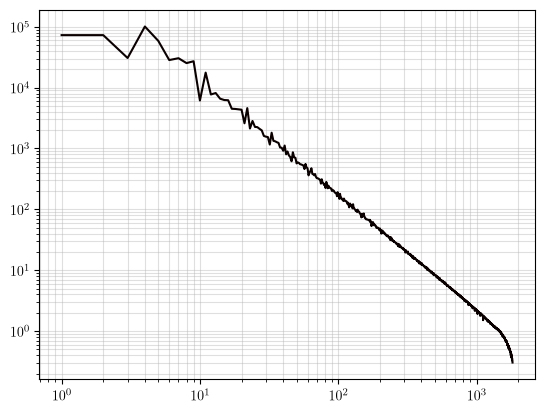

In [14]:

plt.figure()
plt.loglog(np.arange(len(vkp))+1,vkp)
plt.grid(which='both',alpha=0.4)

In [15]:

def int_cost_function(gain,f,f_s,delay_steps,psd_turb,psd_noise,og=1.0):
    den = np.array([1.0,-1.0])
    C = eval_tf(np.array([gain]), den, f, f_s)
    P = np.exp(-1j * 2 * np.pi * f * delay_steps / f_s)
    H_ol = C * P
    den = 1.0 + H_ol*og
    RTF = 1.0 / den
    NTF = H_ol / den
    psd_res = (np.abs(RTF)**2 * psd_turb) + (np.abs(NTF)**2 * psd_noise)
    variance = np.sum(psd_res * np.gradient(f))
    g_crit = 2*np.sin(np.pi/(4*delay_steps-2))
    penalty = variance*gain**2 * (gain>=g_crit*0.98)
    return variance + penalty

def optimize_int_controller(f_s, turb_power=100.0, noise_power=0.5, og=1.0, show:bool=False,
                               delay_steps=2.0, cutoff=15.0, n=1, alias_psd=0.0):

    f = np.linspace(0.1, f_s/2.0, 2000)
    psd_turb, psd_noise = gen_synth_psd(f, cutoff, n, turb_power, noise_power)
    
    if show:
        plt.figure(figsize=(16, 6))
        plt.subplot(1, 2, 1)
        plt.loglog(f, psd_turb/psd_noise, label=f'Turbulence PSD (n={n})', c='k')
        plt.loglog(f, psd_noise/psd_noise, ':',label='Noise Floor', c='gray')
        plt.subplot(1, 2, 2)
        plt.loglog(f, psd_turb, label='Uncorrected Turb', c='k')
        plt.loglog(f, psd_noise+alias_psd, ':', label='Noise floor', c='gray')
    

    init_params = np.array([0.5])
    res = minimize(int_cost_function, init_params, 
                    args=(f, f_s, delay_steps, psd_turb, psd_noise+alias_psd, og),
                    method='Nelder-Mead', 
                    options={'maxiter': 5000, 'adaptive': True})
    
    best_gain = res.x[0]
    den = np.array([1.0,-1.0])
    C = eval_tf(np.array([best_gain]), den, f, f_s)
    P = np.exp(-1j * 2 * np.pi * f * delay_steps / f_s)
    H_ol = C * P
    den = 1.0 + H_ol*og
    RTF = 1.0 / den
    NTF = H_ol / den
    psd_res = (np.abs(RTF)**2 * psd_turb) + (np.abs(NTF)**2 * psd_noise)
    variance = np.sum(psd_res * np.gradient(f))

    return np.sqrt(variance), best_gain

In [ ]:
delayInS = 500e-6
VoverD = 12/D

Nmodes = 1200
rMod = 0

RON = 0.5
res_str = '_1Nm'

orders = [0,1,2,3]

idx = 40

n_subaps = np.array([48,24,16,12])#,36
nModesPerSubaps = np.array([1200,300,150,50])#,600

idx_modes = np.arange(5)

fluxes = np.logspace(6,8,5)#array([5e+8,1e+8,1e+7,3e+6])
freqs = np.linspace(100,4000,20)#500,4) #
# resfs_ao = np.zeros([len(fluxes),len(freqs),len(n_subaps),len(idx_modes)])
# resfs = np.zeros([len(fluxes),len(freqs),len(n_subaps),len(idx_modes)])
resfs = np.zeros([len(orders),len(fluxes),len(freqs),len(n_subaps),len(idx_modes)])

for l,idx in enumerate(idx_modes):
    # for i,flux in enumerate(fluxes):
    #     for j,fs in enumerate(freqs):
    #         Nphot = flux/fs
    #         delay = delayInS*fs+1.0
    #         for k,n_subap in enumerate(n_subaps):
    #             Nm = nModesPerSubaps[k]
    #             if l < Nm:
    #                 if n_subap == 48:
    #                     cov0,og0,_,alias0 = get_rec_covariance(rMod=rMod,n_subap=n_subap,N=Nm,seeing=seeing,Nphot=Nphot,RON=RON,res=res_str)
    #                 else:
    #                     cov0,_,_,_ = get_rec_covariance(rMod=rMod,n_subap=n_subap,N=Nm,seeing=seeing,Nphot=Nphot,RON=RON,res=res_str)
    #                 # resfs[:,i,j,k,l],_,_ = optimize_higher_order_scao(f_s=fs,turb_power=vkp[idx],noise_power=cov0[idx]+alias0[idx]**2,lambda_reg=0.2,show=False,
    #                 #                     n=radial_order(idx),cutoff=0.3*(radial_order(idx)+1)*VoverD,delay_steps=delay,og=og0[idx],orders=orders)
    #                 resfs[i,j,k,l],g = optimize_int_controller(f_s=fs,turb_power=vkp[idx],noise_power=cov0[idx]+alias0[idx]**2,show=False,
    #                                     n=radial_order(idx),cutoff=0.3*(radial_order(idx)+1)*VoverD,delay_steps=delay,og=og0[idx])
                
    for i,flux in enumerate(fluxes):
        for j,fs in enumerate(freqs):
            Nphot = flux/fs
            delay = delayInS*fs+1.0
            for k,n_subap in enumerate(n_subaps):
                Nm = nModesPerSubaps[k]
                if l < Nm:
                    cov0,og0,_,alias0 = get_rec_covariance(rMod=rMod,n_subap=n_subap,N=Nm,seeing=seeing,Nphot=Nphot,RON=RON,res=res_str)
                    resfs[:,i,j,k,l],_,_ = optimize_higher_order_scao(f_s=fs,turb_power=vkp[idx],noise_power=cov0[idx]+alias0[idx]**2,lambda_reg=0.2,show=False,
                                        n=radial_order(idx),cutoff=0.3*(radial_order(idx)+1)*VoverD,delay_steps=delay,og=og0[idx],orders=orders)

Text(0.5, 1.0, 'KL mode 4 residual\nV=12m/s, 1200 modes, 0 $\\lambda/D$')

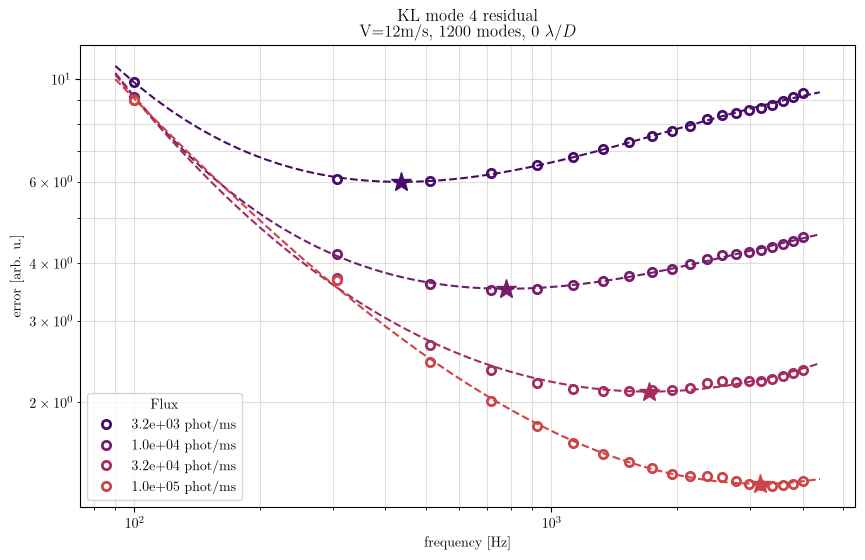

In [ ]:
cmap = mpl.colormaps['inferno'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.1, 0.9, 8)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle

ff = np.linspace(np.min(freqs)*0.9,np.max(freqs)*1.1,400)

mode_idx = 4
ord_id = 0

plt.figure(figsize=(10,6))
for i,flux in enumerate(fluxes[1:]):
    y = resfs[ord_id,i+1,:,0,mode_idx]
    p = np.polyfit(np.log(freqs),np.log(y),deg=3)
    plt.loglog(freqs,y,'o',c=f'C{i+1}',markersize=6,markerfacecolor='white', 
            markeredgewidth=2, label=f'{flux*1e-3:1.1e} phot/ms')
    plt.loglog(ff,np.exp(np.polyval(p,np.log(ff))),'--',c=f'C{i+1}', label='')
    fmin = np.exp((np.sqrt(4*p[1]**2-12*p[0]*p[2])-2*p[1])/(6*p[0]))
    plt.loglog(fmin,np.exp(np.polyval(p,np.log(fmin))),'*',c=f'C{i+1}',markersize=15, label='')
plt.legend(loc='best',title='Flux')
# for i,flux in enumerate(fluxes):
#     y = resfs[i,:,3]
#     p = np.polyfit(np.log(freqs),np.log(y),deg=3)
#     plt.loglog(freqs,y,'^',c=f'C{i+1}',markersize=6,markerfacecolor='white', 
#             markeredgewidth=2, label=f'{flux*1e-3:1.1e} phot/ms')
#     plt.loglog(ff,np.exp(np.polyval(p,np.log(ff))),':',c=f'C{i+1}', label='')
#     fmin = np.exp((np.sqrt(4*p[1]**2-12*p[0]*p[2])-2*p[1])/(6*p[0]))
#     plt.loglog(fmin,np.exp(np.polyval(p,np.log(fmin))),'*',c=f'C{i+1}',markersize=15, label='')
#     # plt.loglog(freqs,resfs_ao[0,i,:,3],'^',c=f'C{i+1}',linestyle=':',
#     #         linewidth=2,markersize=6,markerfacecolor='white', 
#     #         markeredgewidth=2,label=f'{flux*1e-3:1.1e} phot/ms')
plt.grid(which='both',alpha=0.4)
plt.xlabel('frequency [Hz]')
plt.ylabel('error [arb. u.]')
plt.title(f'KL mode {mode_idx} residual\nV={VoverD*D:1.0f}m/s, {Nmodes} modes, {rMod} '+r'$\lambda/D$')

In [ ]:
# import pandas as pd

# freq_vec = np.zeros([len(fluxes),len(freqs),len(n_subaps),len(idx_modes)])
# flux_vec = np.zeros([len(fluxes),len(freqs),len(n_subaps),len(idx_modes)])
# modes_vec = np.zeros([len(fluxes),len(freqs),len(n_subaps),len(idx_modes)])
# subaps_vec = np.zeros([len(fluxes),len(freqs),len(n_subaps),len(idx_modes)])

# for l,idx in enumerate(idx_modes):
#     for i,flux in enumerate(fluxes):
#         for j,fs in enumerate(freqs):
#             for k,n_subap in enumerate(n_subaps):
#                 freq_vec[i,j,k,l] = fs
#                 flux_vec[i,j,k,l] = flux/1e+3
#                 modes_vec[i,j,k,l] = idx
#                 subaps_vec[i,j,k,l] = n_subap

# def save_results(res,fname:str):
#     results = {'freqInHz': freq_vec.flatten(), 'mode_id': modes_vec.flatten(), 'photPerMs': flux_vec.flatten(), 'n_subaps': subaps_vec.flatten(), 'residuals': res.copy().flatten()}
#     columns = ['freqInHz', 'mode_id', 'photPerMs', 'n_subaps', 'residuals']
#     results_df = pd.DataFrame(results, columns=columns) 
#     results_df.to_csv('/raid1/mmenessini/results/RISTRETTOunobs/eb_csv/'+fname+'.csv', index=False)


# save_results(resfs,fname='int_residuals_multistage')
# save_results(resfs_ao,fname='int_residuals_standard')
                


In [ ]:
import pandas as pd

df = pd.read_csv('/raid1/mmenessini/results/RISTRETTOunobs/eb_csv/standard_INT_rMod3.0_s1.30_RON0.5_delay500.0us_VoverD1.46Hz_CL_1Nm.csv')

In [ ]:
cmap = mpl.colormaps['Reds'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 1.0, 10)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle

flux_id = 0
n_subap_id = 0

mode_ids = np.array([0,5,10,20,30,40,45])

plt.figure(figsize=(10,6))
for i,mode in enumerate(mode_ids):
    y = df[0,flux_id,:,n_subap_id,mode]
    p = np.polyfit(np.log(freqs),np.log(y),deg=3)
    fmin = np.exp((np.sqrt(4*p[1]**2-12*p[0]*p[2])-2*p[1])/(6*p[0]))
    plt.loglog(ff,np.exp(np.polyval(p,np.log(ff))),'--',c=f'C{i+1}', label='')
    plt.loglog(fmin,np.exp(np.polyval(p,np.log(fmin))),'*',markersize=8,label=f'{mode}',c=f'C{i+1}')#, label=f'{fluxes[flux_id]/1e+3:1.1e}' )
plt.legend(loc='best',title='Mode')
plt.grid(which='both',alpha=0.4)
plt.xlabel('frequency [Hz]')
plt.ylabel('error [arb. u.]')
plt.ylim([0.5,20])
plt.xlim([50,4000])
plt.title(f'Optimal frequency per mode\n{n_subaps[n_subap_id]}x{n_subaps[n_subap_id]}, {rMod} '+r'$\lambda/D$') #{fluxes[flux_id]/1e+3:1.1e} phot/ms, 

InvalidIndexError: (0, 0, slice(None, None, None), 0, 0)

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'KL mode 40 residual\nflux = 3.2e+04 phot/ms\nV=12m/s, 1200 modes, 0 $\\lambda/D$')

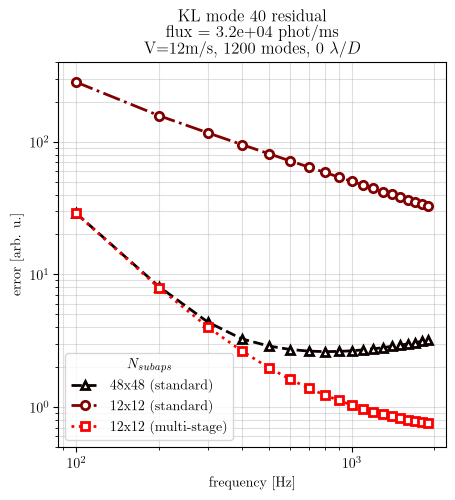

In [ ]:
cmap = mpl.colormaps['hot'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 0.9, 6)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle

flux_id = 3
fmax = 2000

plt.figure()
plt.loglog(freqs[freqs<fmax],resfs_ao[0,flux_id,:,0][freqs<fmax],'^',linestyle='--',
            linewidth=2,markersize=6,markerfacecolor='white', 
            markeredgewidth=2, label=f'48x48 (standard)')
# plt.loglog(freqs[freqs<fmax],resfs[0,flux_id,:,2][freqs<fmax],'o',linestyle='-.',
#             linewidth=2,markersize=6,markerfacecolor='white', 
#             markeredgewidth=2, label=f'24x24 (standard)')
# plt.loglog(freqs[freqs<fmax],resfs_ao[0,flux_id,:,2][freqs<fmax],'s',linestyle=':',
#             linewidth=2,markersize=6,markerfacecolor='white', 
#             markeredgewidth=2, label=f'24x24 (multi-stage)')
plt.loglog(freqs[freqs<fmax],resfs_ao[0,flux_id,:,4][freqs<fmax],'o',linestyle='-.',
            linewidth=2,markersize=6,markerfacecolor='white', 
            markeredgewidth=2, label=f'12x12 (standard)')
plt.loglog(freqs[freqs<fmax],resfs[0,flux_id,:,4][freqs<fmax],'s',linestyle=':',
            linewidth=2,markersize=6,markerfacecolor='white', 
            markeredgewidth=2, label=f'12x12 (multi-stage)')
plt.legend(loc='best',title=r'$N_{subaps}$')
plt.grid(which='both',alpha=0.4)
plt.ylim([0.5,400])
plt.xlabel('frequency [Hz]')
plt.ylabel('error [arb. u.]')
plt.title(f'KL mode {idx} residual\nflux = {fluxes[flux_id]*1e-3:1.1e} phot/ms\nV={VoverD*D:1.0f}m/s, {Nmodes} modes, {rMod} '+r'$\lambda/D$')

Text(0.5, 1.0, 'KL mode 40 residual\nflux = 3.2e+03 phot/ms\nV=12m/s, 1200 modes, 0 $\\lambda/D$')

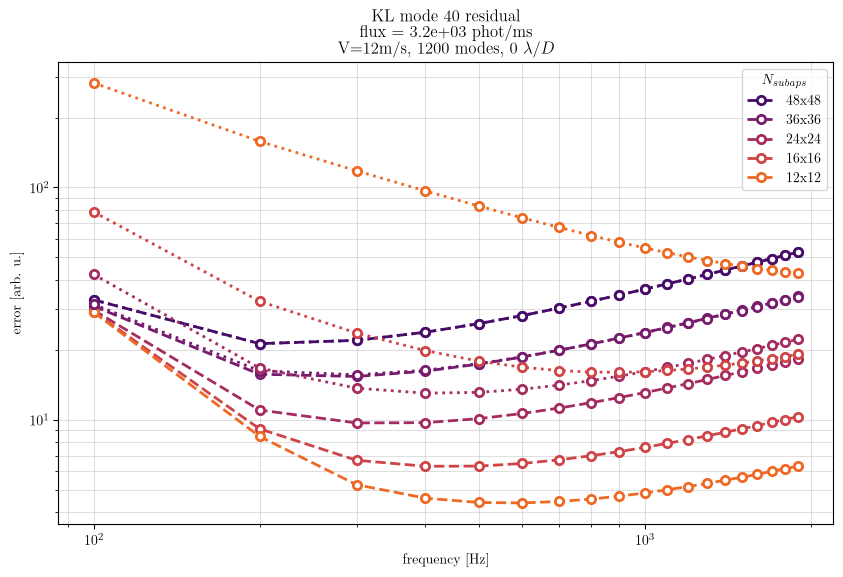

In [ ]:
flux_id = 1

fmax = 2000

plt.figure(figsize=(10,6))
for i,n_subap in enumerate(n_subaps):
    plt.loglog(freqs[freqs<fmax],resfs[0,flux_id,:,i][freqs<fmax],'o',c=f'C{i+1}',linestyle='--',
            linewidth=2,markersize=6,markerfacecolor='white', 
            markeredgewidth=2, label=f'{n_subap}x{n_subap}')
plt.legend(loc='best',title=r'$N_{subaps}$')
plt.grid(which='both',alpha=0.4)
plt.xlabel('frequency [Hz]')
plt.ylabel('error [arb. u.]')
plt.title(f'KL mode {idx} residual\nflux = {fluxes[flux_id]*1e-3:1.1e} phot/ms\nV={VoverD*D:1.0f}m/s, {Nmodes} modes, {rMod} '+r'$\lambda/D$')

In [ ]:
freqs = np.array([1,2,3,4,5])*1e+3

VoverD = 20/D
n_subap = 48
Nphot = 4e+7 # phot/s
RON = 0.5
res_str = '_1Nm'
N = 1200

orders = [0,1,3]
res = np.zeros([len(freqs),len(orders),N])

for j,freq in enumerate(freqs):
    cov0,og0,ct0,alias0 = get_rec_covariance(rMod=0,n_subap=n_subap,N=N,seeing=seeing,Nphot=Nphot/freq,RON=RON,res=res_str)
    delay = 250e-6*freq + 1
    for idx in range(120):
        res[j,:,idx],_,_ = optimize_higher_order_scao(f_s=freq,turb_power=vkp[idx],noise_power=cov0[idx]+alias0[idx]**2,show=False, #alias_psd=alias_psd,
                            n=radial_order(idx),cutoff=0.3*(radial_order(idx)+1)*VoverD,delay_steps=delay,og=og0[idx],orders=orders)

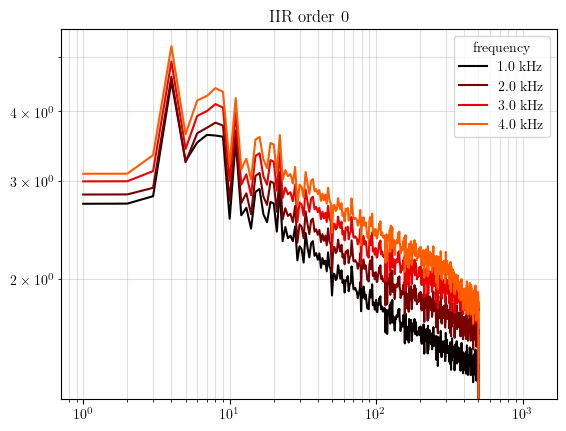

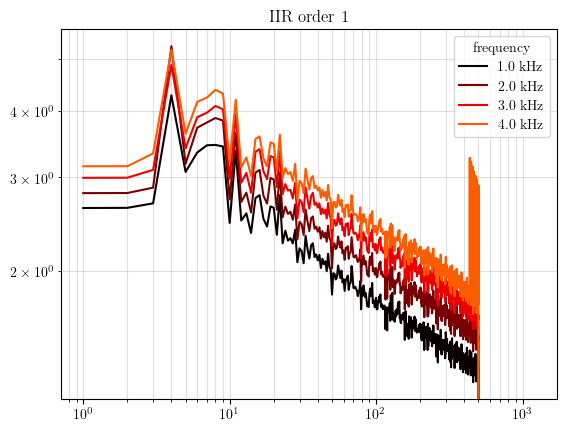

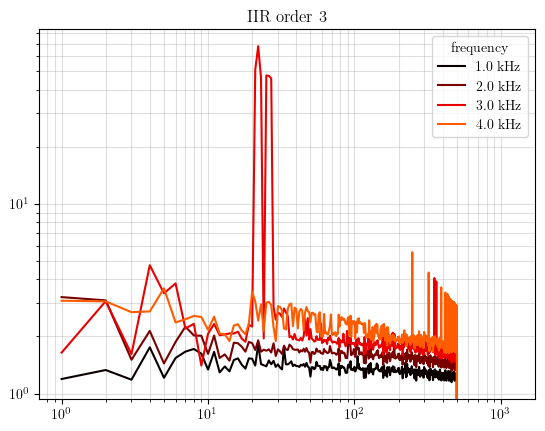

In [ ]:
x = np.arange(N)+1

for i,order in enumerate(orders):
    plt.figure()
    for j,freq in enumerate(freqs[:-1]):
        plt.loglog(x,res[j,i],label=f'{freq/1e+3:1.1f} kHz')
    plt.legend(title='frequency')
    plt.grid(which='both',alpha=0.4)
    plt.title(f'IIR order {order}')